In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [2]:
df = pd.read_csv("../../data/weatherAUS_ForModel.csv")

X = df.drop(columns=["RainTomorrow", "Date", "SeasonName"], errors="ignore")
y = df["RainTomorrow"]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
#calcul de déséquilibre
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)
ratio = neg / pos

Gridsearch

In [6]:
param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [200, 300]
}

grid = GridSearchCV(
    XGBClassifier(
        scale_pos_weight=ratio,
        eval_metric="logloss",
        random_state=42
    ),
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

In [7]:
grid.fit(X_train, y_train)
print("Best parameters :", grid.best_params_)
print("Best score :", grid.best_score_)

Best parameters : {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}
Best score : 0.8899289921613113


Une recherche d’hyperparamètres a permis d’identifier une configuration optimale du modèle XGBoost (max_depth=7, learning_rate=0.1, n_estimators=300), améliorant significativement les performances avec un ROC-AUC de 0.889.

In [9]:
best_model = XGBClassifier(
    learning_rate=0.1,
    max_depth=7,
    n_estimators=300,
    scale_pos_weight=ratio,
    eval_metric="logloss",
    random_state=42
)

best_model.fit(X_train, y_train)

y_proba = best_model.predict_proba(X_test)[:,1]
threshold = 0.45
y_pred = (y_proba >= threshold).astype(int)



print("ROC-AUC :", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

ROC-AUC : 0.8942634086113057
              precision    recall  f1-score   support

           0       0.93      0.83      0.88     21757
           1       0.57      0.79      0.66      6262

    accuracy                           0.82     28019
   macro avg       0.75      0.81      0.77     28019
weighted avg       0.85      0.82      0.83     28019



La phase de tuning a permis d’optimiser les hyperparamètres du modèle XGBoost, améliorant ainsi ses performances globales.

Avant tuning, le modèle obtenait un ROC-AUC élevé (~0.89), mais cette estimation était optimiste car basée sur un simple découpage des données.

La validation croisée a révélé une performance plus réaliste (ROC-AUC ≈ 0.83) ainsi qu’une variabilité modérée, indiquant une certaine sensibilité du modèle aux données.

Après optimisation, le modèle atteint un ROC-AUC de 0.894, tout en améliorant la détection de la classe minoritaire (recall = 0.79).

Ces résultats montrent que le tuning permet non seulement d’améliorer les performances, mais aussi d’obtenir un modèle plus robuste et mieux adapté au problème.

Feature importance

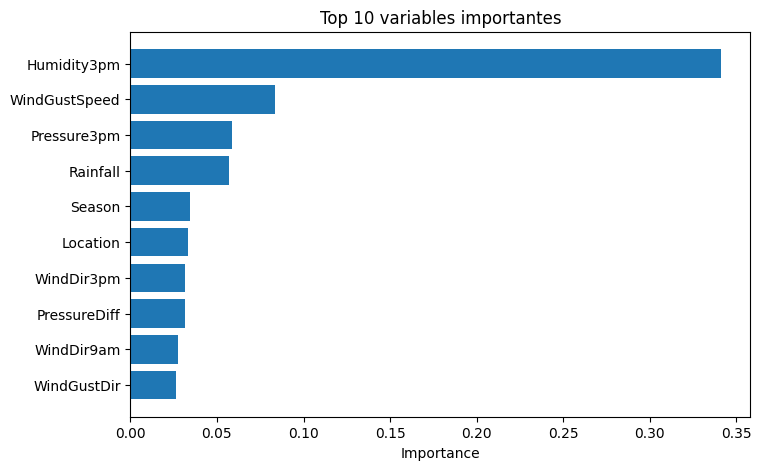

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Feature importance
importances = best_model.feature_importances_

indices = np.argsort(importances)[-10:]

plt.figure(figsize=(8,5))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.title("Top 10 variables importantes")
plt.xlabel("Importance")
plt.show()

Analyse des erreurs

In [11]:
fp = (y_test == 0) & (y_pred == 1)
fn = (y_test == 1) & (y_pred == 0)

print("Faux positifs :", fp.sum())
print("Faux négatifs :", fn.sum())

Faux positifs : 3726
Faux négatifs : 1317


L’analyse des erreurs montre que le modèle génère davantage de faux positifs (3726) que de faux négatifs (1317). Cela indique qu’il privilégie la détection des événements de pluie, même au prix de fausses alertes. Ce comportement est pertinent dans ce contexte, où il est préférable de ne pas manquer un événement de pluie.
Les faux positifs peuvent correspondre à des situations météorologiques proches de la pluie (forte humidité, pression basse), ce qui explique leur fréquence.

PR COURBE

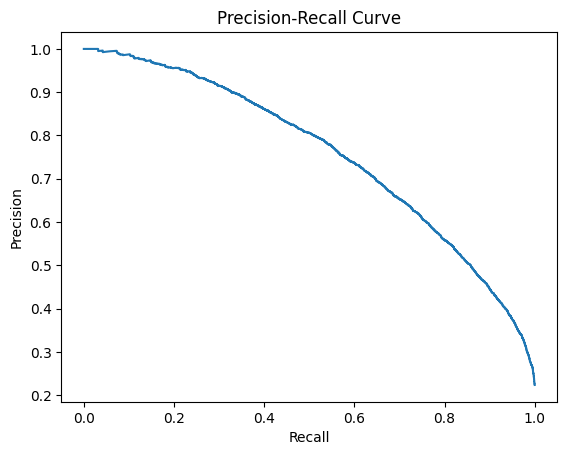

In [12]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

La courbe Precision-Recall montre un compromis classique entre précision et rappel. Lorsque le recall augmente, la précision diminue, ce qui est attendu dans un problème déséquilibré. Le modèle présente de bonnes performances globales, avec une capacité satisfaisante à détecter les événements de pluie tout en maintenant une précision raisonnable.